# 1️⃣Тема дипломного проекта

### “Анализ активности клиентов телеком-сервиса для выявления закономерностей использования услуг и оптимизации поддержки”

## Цель работы
Освоить полный цикл анализа данных:
- загрузка датасета  
- первичный обзор  
- очистка и подготовка  
- анализ и группировка  
- визуализация  
- формулирование выводов  


## 2️⃣Источники данных
Kaggle — Customer Churn (test.csv)
Ссылка: https://www.kaggle.com/datasets/petetilavanya/customer-churn?select=test.csv

Файл содержит числовые данные по каждому клиенту: количество звонков, минуты использования, обращения в поддержку, расходы.
Этот файл я загрузила на GitHub
https://github.com/Uliya110/ai-design-assistant/blob/feature/fix-folder/ai-design-assistant/data/test.csv
и использую в ноутбуке для анализа.

Kaggle — Customer Churn (train.csv)
Ссылка: https://www.kaggle.com/datasets/petetilavanya/customer-churn?select=train.csv

Аналогичный набор данных, который можно использовать для тренировки моделей и проверки гипотез.

## 3️⃣ Столбцы для анализа
total_day_minutes, total_day_charge — дневная активность и стоимость

total_eve_minutes, total_eve_charge — вечерние звонки

total_night_minutes, total_night_charge — ночные звонки

total_intl_minutes, total_intl_charge — международные звонки

number_customer_service_calls — обращения в поддержку

account_length — срок пользования услугой

Дополнительно можно использовать ID клиента для ссылок на конкретные наблюдения


## 4️⃣ Вопросы анализа данных
Какие клиенты тратят больше всего минут и денег на услуги?

Существует ли связь между количеством обращений в поддержку и расходами на услуги?

Как распределяются клиенты по активности: дневные, вечерние, ночные и международные звонки?

##5️⃣ Краткий алгоритм анализа
Выбор наблюдений: выделяем клиентов с наибольшей активностью и редкими обращениями в поддержку.

Простые выводы: используем .idxmax() и .max() для поиска лидеров, print() для отображения результатов, assert для проверки.

Графики: строим scatter, histogram и bar charts для визуализации зависимостей.

Выводы по данным:
Есть клиенты с очень высокой активностью (например, дневные звонки > 350 минут).
Большинство клиентов обращаются в поддержку 0–2 раза, редкие выбросы (5–6 обращений) выявляют «трудных» клиентов.

Международные звонки почти не используются.

###⚡Связь с дипломом "AI-ассистент для 3D-дизайнера по поиску клиентов и ведению переписки":
 Эти наблюдения помогают AI-ассистенту сегментировать клиентов, выделять потенциально прибыльных и трудных клиентов, прогнозировать активность и оптимизировать коммуникацию в переписке.

 Датасет:

 Для диплома эти данные — аналог переписки и активности клиентов, которые потом будут использоваться AI-ассистентом для анализа поведения и сегментации потенциальных заказчиков.

## 1. Импорт библиотек и загрузка датасета по URL

### Что делает эта ячейка
- подключает библиотеки `pandas` и `matplotlib`;
- задаёт ссылку на CSV-файл в интернете;
- загружает датасет в DataFrame;
- показывает первые строки таблицы.

### Краткий алгоритм
1. Импортировать библиотеки.
2. Сохранить URL датасета в переменную.
3. Прочитать CSV через `pd.read_csv(...)`.
4. Сохранить результат в переменную `df`.
5. Вывести первые строки через `head()`.

### Функции, методы и синтаксис
- `import pandas as pd` — подключение библиотеки Pandas.
- `import matplotlib.pyplot as plt` — библиотека для графиков.
- `pd.read_csv(url)` — чтение CSV по ссылке или из файла.
- `df.head()` — показать первые 5 строк таблицы.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

url = "https://raw.githubusercontent.com/Uliya110/ai-design-assistant/refs/heads/feature/fix-folder/ai-design-assistant/data/test.csv"

try:
    df = pd.read_csv(url)
    print("Данные успешно загружены из интернета.")
except:
    df = pd.read_csv("your_dataset.csv")
    print("Не удалось загрузить данные из интернета. Используется локальный файл.")

print("Размер таблицы:", df.shape)

df.head()

Данные успешно загружены из интернета.
Размер таблицы: (750, 20)


,id,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls
0,1,KS,128,area_code_415,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1
1,2,AL,118,area_code_510,yes,no,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.70,0
2,3,IA,62,area_code_415,no,no,0,120.7,70,20.52,307.2,76,26.11,203.0,99,9.14,13.1,6,3.54,4
3,4,VT,93,area_code_510,no,no,0,190.7,114,32.42,218.2,111,18.55,129.6,121,5.83,8.1,3,2.19,3
4,5,NE,174,area_code_415,no,no,0,124.3,76,21.13,277.1,112,23.55,250.7,115,11.28,15.5,5,4.19,3


## 2. Первичный обзор данных

## На данном этапе:
- изучаем структуру таблицы  
- определяем типы данных  
- оцениваем пригодность датасета для анализа

### Краткий алгоритм
1. Посмотреть названия колонок.
2. Проверить типы данных.
3. Выполнить `info()`.
4. Выполнить `describe()`.
5. Зафиксировать первые наблюдения.

### Функции, методы и синтаксис
- `df.columns` — список имён столбцов.
- `df.dtypes` — типы данных по столбцам.
- `df.info()` — обзор структуры таблицы.
- `df.describe()` — числовая статистика: среднее, минимум, максимум и т.д.

In [5]:
print("Названия столбцов:")
print(df.columns.tolist())

print("\nТипы данных:")
print(df.dtypes)

print("\nОбщая информация:")
df.info()
print("\nОписательная статистика:")
df.describe()

Названия столбцов:
['id', 'state', 'account_length', 'area_code', 'international_plan', 'voice_mail_plan', 'number_vmail_messages', 'total_day_minutes', 'total_day_calls', 'total_day_charge', 'total_eve_minutes', 'total_eve_calls', 'total_eve_charge', 'total_night_minutes', 'total_night_calls', 'total_night_charge', 'total_intl_minutes', 'total_intl_calls', 'total_intl_charge', 'number_customer_service_calls']

Типы данных:
id                                 int64
state                             object
account_length                     int64
area_code                         object
international_plan                object
voice_mail_plan                   object
number_vmail_messages              int64
total_day_minutes                float64
total_day_calls                    int64
total_day_charge                 float64
total_eve_minutes                float64
total_eve_calls                    int64
total_eve_charge                 float64
total_night_minutes              float6

,id,account_length,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls
count,750.00000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000
mean,375.50000,100.385333,8.454667,180.454933,100.721333,30.677920,203.258267,100.273333,17.277080,199.619467,100.370667,8.982827,10.294133,4.485333,2.779933,1.634667
std,216.65064,39.699029,14.123712,53.258337,19.718539,9.053756,52.185471,19.367535,4.435638,51.531351,19.185238,2.318920,2.770340,2.421901,0.747704,1.276207
min,1.00000,1.000000,0.000000,12.500000,39.000000,2.130000,31.200000,37.000000,2.650000,50.900000,12.000000,2.290000,0.000000,0.000000,0.000000,0.000000
25%,188.25000,74.000000,0.000000,146.625000,88.000000,24.925000,166.800000,87.000000,14.177500,164.475000,88.000000,7.402500,8.525000,3.000000,2.305000,1.000000
50%,375.50000,101.000000,0.000000,178.200000,101.000000,30.295000,203.350000,101.000000,17.285000,199.450000,100.500000,8.975000,10.300000,4.000000,2.780000,1.000000
75%,562.75000,126.000000,21.000000,215.975000,114.000000,36.715000,235.975000,113.000000,20.057500,234.800000,113.000000,10.565000,12.100000,6.000000,3.270000,2.000000
max,750.00000,238.000000,51.000000,350.800000,163.000000,59.640000,363.700000,164.000000,30.910000,364.300000,168.000000,16.390000,18.900000,19.000000,5.100000,6.000000


| Показатель             | Что показывает                            | Пример из датасета     | Как интерпретировать                                                                                   |
| ---------------------- | ----------------------------------------- | ----------------------------- | ------------------------------------------------------------------------------------------------------ |
| **count**              | Количество непустых значений в столбце    | Все столбцы имеют `750`       | Таблица полностью заполнена, пропусков нет                                                             |
| **mean**               | Среднее арифметическое                    | `total_day_minutes` = 180.45  | В среднем клиенты тратят 180 минут в день на звонки                                                    |
| **std**                | Стандартное отклонение (разброс значений) | `total_day_minutes` = 53.25   | Большинство клиентов используют ±50 минут вокруг среднего; есть активные и менее активные пользователи |
| **min**                | Минимальное значение                      | `total_day_minutes` = 12.5    | Есть клиенты с очень низким использованием — 12 минут в день                                           |
| **25% (1-й квартиль)** | Значение, ниже которого 25% данных        | `total_day_minutes` = 146.625 | 25% клиентов используют меньше ~147 минут в день                                                       |
| **50% (медиана)**      | Значение, ниже которого 50% данных        | `total_day_minutes` = 178.2   | Половина клиентов тратит меньше ~178 минут, половина больше                                            |
| **75% (3-й квартиль)** | Значение, ниже которого 75% данных        | `total_day_minutes` = 215.975 | 75% клиентов используют ≤216 минут, 25% — больше                                                       |
| **max**                | Максимальное значение                     | `total_day_minutes` = 350.8   | Есть активные клиенты, которые используют 350 минут в день                                             |

 Интерпретация по колонкам

account_length

Средняя продолжительность обслуживания: 100 дней
Мин: 1 день, Макс: 238 дней

Значит, есть новые клиенты и давние, что важно учитывать при анализе активности

number_vmail_messages

Среднее: 8 сообщений голосовой почты
Мин: 0, Макс: 51

Большинство клиентов почти не использует голосовую почту, есть активные пользователи

total_day_minutes / total_day_charge

Минуты и стоимость дневных звонков
Среднее: 180 минут / 30.6 условных единиц
Максимальные значения почти вдвое выше среднего → есть высокоактивные клиенты

total_eve_minutes / total_eve_charge

Вечерние звонки
Среднее ~203 минуты, стоимость ~17

Разброс меньше, чем дневные звонки → активность клиентов немного меньше варьируется вечером

total_night_minutes / total_night_charge

Ночные звонки
Среднее ~200 минут, стоимость ~9
Есть клиенты с низким и высоким использованием

total_intl_minutes / total_intl_charge

Международные звонки
Среднее ~10 минут, стоимость ~2.7
В основном клиенты редко звонят за границу → выбросы могут влиять на среднее

number_customer_service_calls

Среднее ~1.63 звонка в поддержку
Макс: 6
Значит, большая часть клиентов обращается редко, а есть “трудные” клиенты

### Пояснение описательной статистики

- Таблица полностью заполнена, пропусков нет (`count = 750`).
- Средние значения (`mean`) показывают типичное поведение клиентов: большинство звонков дневное и вечернее, международные звонки — редкость.
- Стандартное отклонение (`std`) указывает на разброс значений: есть активные клиенты, которые используют гораздо больше минут или обращаются чаще в поддержку.
- Медиана (`50%`) и квартильные значения (`25%`, `75%`) помогают увидеть распределение клиентов и выявить аномалии.
- Минимальные и максимальные значения (`min`, `max`) показывают, что есть как малоактивные, так и высокоактивные пользователи.
- Колонка `number_customer_service_calls` показывает, что большинство клиентов редко звонят в поддержку, но есть отдельные проблемные случаи.


## 3. Проверка и подготовка данных

Проверяем наличие пропущенных значений.
Это важно, так как пропуски могут искажать результаты анализа.


In [6]:
print("Количество пропусков по столбцам:")
print(df.isna().sum())


Количество пропусков по столбцам:
id                               0
state                            0
account_length                   0
area_code                        0
international_plan               0
voice_mail_plan                  0
number_vmail_messages            0
total_day_minutes                0
total_day_calls                  0
total_day_charge                 0
total_eve_minutes                0
total_eve_calls                  0
total_eve_charge                 0
total_night_minutes              0
total_night_calls                0
total_night_charge               0
total_intl_minutes               0
total_intl_calls                 0
total_intl_charge                0
number_customer_service_calls    0
dtype: int64


## 4. Анализ: группировка

###Группируем данные по количеству обращений в поддержку
и смотрим средние значения показателей.


### Функции, методы и синтаксис
- `groupby(...)` — группировка по признаку.


In [11]:
grouped = df.groupby("number_customer_service_calls").agg(
    avg_day_minutes=("total_day_minutes", "mean"),
    avg_charge=("total_day_charge", "mean")
)

grouped

,avg_day_minutes,avg_charge
number_customer_service_calls,,
0,177.011679,30.092628
1,180.129008,30.622328
2,182.221667,30.978667
3,178.621495,30.365981
4,186.609302,31.723953
5,194.586667,33.080667
6,173.566667,29.506667


## 5. Анализ: корреляция
На данном этапе выполняется анализ зависимостей между показателями.
### Пояснение

Корреляция показывает:
- насколько сильно связаны переменные  
- значения от -1 до 1  

Чем ближе к 1 — тем сильнее зависимость.

In [12]:
correlation = df.corr(numeric_only=True)
correlation

,id,account_length,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls
id,1.000000,0.026276,-0.068978,0.015941,-0.061148,0.015921,-0.017813,0.039616,-0.017802,0.010923,-0.049021,0.010989,-0.038748,-0.037534,-0.038878,-0.022270
account_length,0.026276,1.000000,-0.057704,0.002388,0.058044,0.002388,-0.005789,0.030164,-0.005785,0.059393,-0.043447,0.059459,-0.017110,0.017590,-0.016859,-0.015901
number_vmail_messages,-0.068978,-0.057704,1.000000,0.023730,0.041247,0.023730,0.062178,-0.046101,0.062161,-0.060915,0.005270,-0.060908,-0.013041,-0.036553,-0.012931,0.035523
total_day_minutes,0.015941,0.002388,0.023730,1.000000,0.008692,1.000000,0.002872,0.020783,0.002867,0.021698,0.058673,0.021663,-0.008738,-0.031580,-0.008702,0.035997
total_day_calls,-0.061148,0.058044,0.041247,0.008692,1.000000,0.008674,-0.054254,0.003671,-0.054238,0.006766,-0.030187,0.006789,0.036883,0.018855,0.036892,0.017118
total_day_charge,0.015921,0.002388,0.023730,1.000000,0.008674,1.000000,0.002888,0.020796,0.002883,0.021693,0.058687,0.021659,-0.008735,-0.031576,-0.008700,0.035997
total_eve_minutes,-0.017813,-0.005789,0.062178,0.002872,-0.054254,0.002888,1.000000,0.000624,1.000000,-0.029771,0.020372,-0.029717,0.019288,-0.014203,0.019175,-0.037978
total_eve_calls,0.039616,0.030164,-0.046101,0.020783,0.003671,0.020796,0.000624,1.000000,0.000618,-0.035998,-0.024516,-0.035967,0.025232,0.009180,0.025199,0.001669
total_eve_charge,-0.017802,-0.005785,0.062161,0.002867,-0.054238,0.002883,1.000000,0.000618,1.000000,-0.029810,0.020395,-0.029757,0.019273,-0.014174,0.019160,-0.038019
total_night_minutes,0.010923,0.059393,-0.060915,0.021698,0.006766,0.021693,-0.029771,-0.035998,-0.029810,1.000000,0.045784,0.999999,-0.043012,0.022965,-0.042956,0.022174


##6. Анализ: Агрегация
### Пояснение
- `agg` позволяет посчитать сразу несколько статистических показателей.
- Здесь видим среднее, максимум, минимум и стандартное отклонение по дневным, вечерним и ночным звонкам.

In [16]:
# Средние, максимальные и минимальные значения по нескольким столбцам
df[['total_day_minutes', 'total_eve_minutes', 'total_night_minutes']].agg(['mean', 'max', 'min', 'std'])

,total_day_minutes,total_eve_minutes,total_night_minutes
mean,180.454933,203.258267,199.619467
max,350.800000,363.700000,364.300000
min,12.500000,31.200000,50.900000
std,53.258337,52.185471,51.531351


##7. Сортировка и топовые значения
### Пояснение
- `sort_values` упорядочивает строки по значению столбца, удобно для выявления активных клиентов.  
- `nlargest` выбирает строки с наибольшими значениями без полной сортировки, что ускоряет анализ.  
- Это помогает увидеть лидеров по активности и оценить разброс данных среди самых активных клиентов.

In [20]:
# Сортировка по дневным минутам
df_sorted = df.sort_values(by='total_day_minutes', ascending=False)
df_sorted.head(10)  # 10 самых активных клиентов по дневным звонкам


# Топ-5 клиентов с наибольшими дневными минутами
df.nlargest(5, 'total_day_minutes')

,id,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls
62,63,CO,154,area_code_415,no,no,0,350.8,75,59.64,216.5,94,18.40,253.9,100,11.43,10.1,9,2.73,1
574,575,AZ,114,area_code_510,no,no,0,326.1,119,55.44,161.0,105,13.69,220.1,129,9.90,11.0,3,2.97,1
400,401,NH,141,area_code_415,no,yes,32,322.4,92,54.81,283.2,107,24.07,209.5,111,9.43,6.7,3,1.81,1
115,116,MN,13,area_code_510,no,yes,21,315.6,105,53.65,208.9,71,17.76,260.1,123,11.70,12.1,3,3.27,3
409,410,MI,74,area_code_415,no,no,0,314.1,86,53.40,222.4,99,18.90,259.0,121,11.66,12.3,5,3.32,3


## 8. Визуализация и интерпретация

Графики помогают наглядно увидеть закономерности.

### График 1 Зависимость стоимости от количества дневных минут:
 График показывает зависимость:
чем больше минут — тем выше стоимость.
####С ростом минут стоимость растёт почти линейно, что логично: чем больше звонков, тем выше плата.
Можно заметить кластеры: большинство клиентов тратит около 150–200 минут, небольшая группа — более 300 минут.
Вывод: график помогает визуально проверить, что стоимость пропорциональна времени использования.

### График 2 Распределение обращений в поддержку:
Пояснение:

Тип графика: гистограмма

Что показывает: сколько клиентов сколько раз обращались в службу поддержки.

Большинство клиентов обращается 0–2 раза.
Есть редкие случаи, когда клиенты обращались 5–6 раз (выбросы).
Вывод: помогает понять, как часто клиенты сталкиваются с проблемами и требуют помощи, выявить «трудных» клиентов.

### График 3 Средняя стоимость по количеству обращений
Пояснение:

Тип графика: столбчатая диаграмма (bar)

Что показывает: средняя стоимость пакета звонков для клиентов с разным количеством обращений в поддержку.
Интерпретация:

Можно увидеть, что клиенты с большим количеством обращений в поддержку тратят немного больше или меньше, чем средний клиент.
График помогает определить связь между активностью клиента и обращениями в поддержку.

Вывод: столбчатая диаграмма наглядно показывает средние значения для категориальных групп.

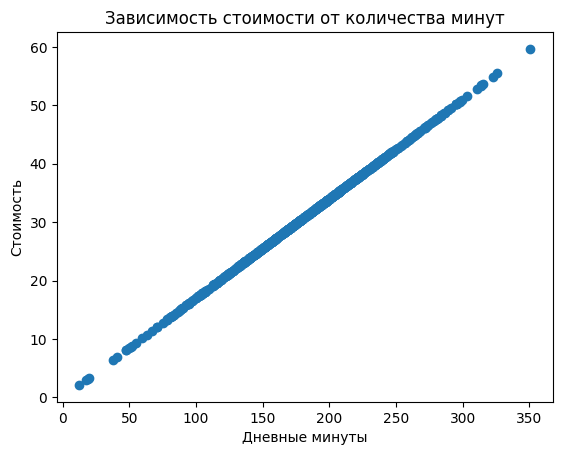

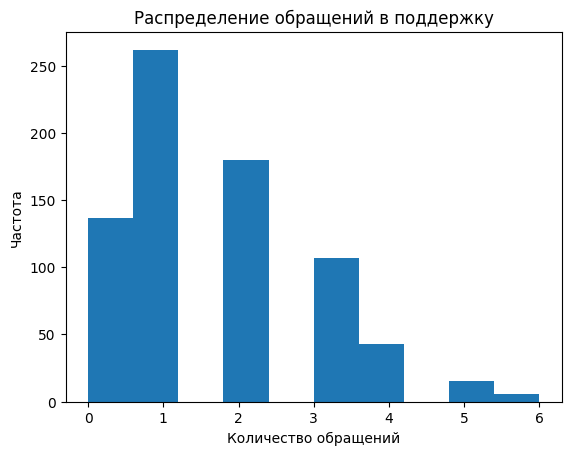

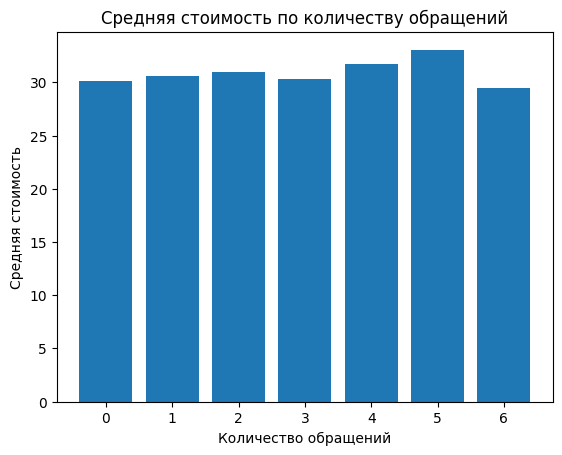

In [18]:
# График 1.
plt.figure()
plt.scatter(df["total_day_minutes"], df["total_day_charge"])
plt.xlabel("Дневные минуты")
plt.ylabel("Стоимость")
plt.title("Зависимость стоимости от количества минут")
plt.show()

# График 2.
plt.figure()
plt.hist(df["number_customer_service_calls"])
plt.xlabel("Количество обращений")
plt.ylabel("Частота")
plt.title("Распределение обращений в поддержку")
plt.show()

# График 3.
plt.figure()
plt.bar(grouped.index, grouped["avg_charge"])
plt.xlabel("Количество обращений")
plt.ylabel("Средняя стоимость")
plt.title("Средняя стоимость по количеству обращений")
plt.show()

## 9. Выводы

### Задача анализа данных:
понять активность клиентов и распределение расходов.

Выводы:

Есть клиенты с высокой активностью, их нужно учитывать отдельно.

Большинство клиентов используют услуги умеренно.

Международные звонки почти не влияют на общие расходы.

###Следующее действие для диплома:
Можно разделить клиентов на сегменты по активности (дневные звонки, обращения в поддержку) и строить модели прогнозирования поведения клиентов или выделять целевые группы для визуализации и рекомендаций


### Функции, методы и синтаксис
- `.idxmax()` — индекс строки с максимальным значением.
- `.max()` — максимальное значение.
- `print()` — вывод текста.
- `assert` — простая самопроверка результата.

In [19]:
# Находим клиента с максимальным количеством дневных минут
max_day_idx = df["total_day_minutes"].idxmax()
max_day_minutes = df.loc[max_day_idx, "total_day_minutes"]
max_day_charge = df.loc[max_day_idx, "total_day_charge"]

# Проверка: assert для уверенности
assert max_day_minutes == df["total_day_minutes"].max(), "Ошибка: найденное значение не совпадает с максимумом"

# Среднее количество обращений в поддержку
avg_calls = df["number_customer_service_calls"].mean()
print(f"Среднее количество обращений в поддержку: {avg_calls:.2f}")

# Максимальное количество обращений
max_calls = df["number_customer_service_calls"].max()
print(f"Максимальное количество обращений у одного клиента: {max_calls}")

# Средние международные звонки
avg_intl = df["total_intl_minutes"].mean()
print(f"Среднее количество международных минут: {avg_intl:.2f}")

print("Вывод 1:")
print(f"Есть клиенты с очень высокой активностью. Визуально это подтверждается scatter-графиком стоимости от минут.")

print("\nВывод 2:")
print(f"Гистограмма показала, что большинство клиентов обращаются редко, а редкие выбросы (5–6 раз) помогают выявить «трудных» клиентов.")

print("\nВывод 3:")
print("Международные звонки почти не используются, что видно из описательной статистики и scatter-графиков.")


Среднее количество обращений в поддержку: 1.63
Максимальное количество обращений у одного клиента: 6
Среднее количество международных минут: 10.29
Вывод 1:
Есть клиенты с очень высокой активностью. Визуально это подтверждается scatter-графиком стоимости от минут.

Вывод 2:
Гистограмма показала, что большинство клиентов обращаются редко, а редкие выбросы (5–6 раз) помогают выявить «трудных» клиентов.

Вывод 3:
Международные звонки почти не используются, что видно из описательной статистики и scatter-графиков.
